In [1]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function

In [2]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [3]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [4]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [5]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 1 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.32f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()  

In [6]:
class CReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        pos = torch.relu(input)
        neg = torch.relu(-input)
        return torch.cat((pos, neg), dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        channels = input.shape[1]
        grad_pos = grad_output[:, :channels]
        grad_neg = grad_output[:, channels:]

        grad_input = grad_pos * (input > 0).float() - grad_neg * (input < 0).float()

        return grad_input


class CReLU(nn.Module):
    def forward(self, x):
        return CReLUFunction.apply(x)


class StableNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.first_norm = nn.BatchNorm1d(n, affine=False, track_running_stats=True)
        self.activation = CReLU()

        self.pre_norms = nn.ModuleList()
        self.linears = nn.ModuleList()
        self.post_norms = nn.ModuleList()

        for _ in range(num_layers):
            self.pre_norms.append(nn.BatchNorm1d(n * 2, affine=False, track_running_stats=True))

            self.linears.append(nn.Linear(n * 2, n, bias=False))
            with torch.no_grad():
                nn.init.zeros_(self.linears[-1].weight) # type: ignore

            self.post_norms.append(nn.BatchNorm1d(n, affine=False, track_running_stats=True))
            n *= 2

        self.final_norm = nn.BatchNorm1d(n * 2, affine=False, track_running_stats=True)
        self.final_linear = nn.Linear(n * 2, 2, bias=True)
        with torch.no_grad():
            nn.init.zeros_(self.final_linear.weight)
            nn.init.zeros_(self.final_linear.bias)

    def forward(self, x):
        x = self.first_norm(x)

        for prenorm, linear, postnorm in zip(self.pre_norms, self.linears, self.post_norms):
            residual = x

            x = self.activation(x)
            x = prenorm(x)
            x = linear(x)

            x = torch.cat([residual, postnorm(x + residual)], dim=1)

        x = self.activation(x)
        x = self.final_norm(x)
        return self.final_linear(x)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-6                        [43152, 28]               --
│    └─Modu

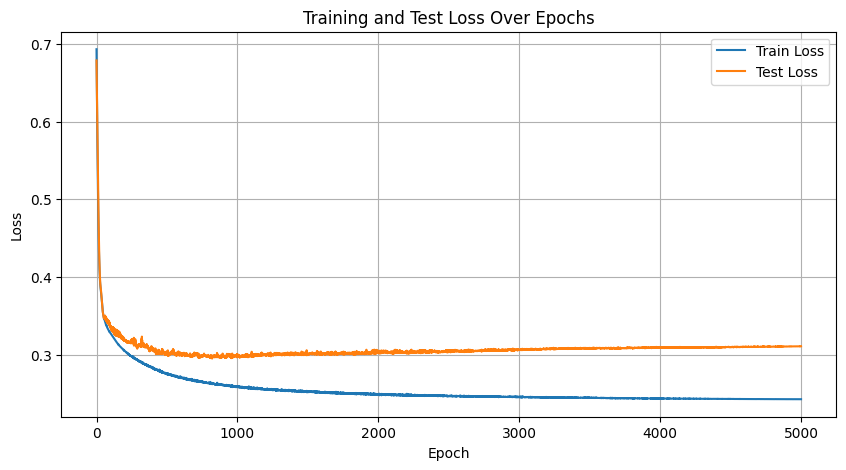

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.2588,  0.2264,  1.1867,  0.0371, -2.4915,  1.4286,  0.1881, -1.1955,
         -0.0623, -0.0149,  0.4394,  0.5729, -0.0199,  0.5633],
        [-0.2732,  0.9717, -0.1466,  0.4965, -1.4618,  2.2393, -0.5863,  0.2625,
          0.2729,  0.0211, -0.1079, -0.1626, -0.9455,  2.0878],
        [ 0.3069,  0.4116,  1.6794, -0.3025,  0.5871, -0.3956, -0.1706, -0.1990,
          0.2024,  0.1423,  0.1520,  0.4921, -0.9381,  0.6245],
        [-0.0413,  0.2032,  1.4208,  0.1639,  1.2720, -1.4428,  1.6791,  0.0914,
          0.2817,  0.1973,  0.2587,  1.7923, -0.3426,  0.1152],
        [-0.9960, -1.0011,  0.0566, -0.0585,  0.9902,  0.0897, -0.2457, -0.1465,
          0.7653, -0.4099,  0.3447, -2.2778,  2.1001,  0.6385],
        [ 2.0820,  0.0100, -0.0760, -0.1294,  0.2397, -0.8395, -0.2408, -0.4779,
          0.4695, -0.0551,  0.3583,  2.9530, -2.1475, -0.6571],
        [-1.4436,  0.7470,  0.7685,  0.0625,  0.4370,  2.0215, -0.0060,  1.9079,


In [8]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                2,284
Total params: 2,284
Trainable params: 2,284
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 1.21
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 1.21
_orig_mod.linears.0.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

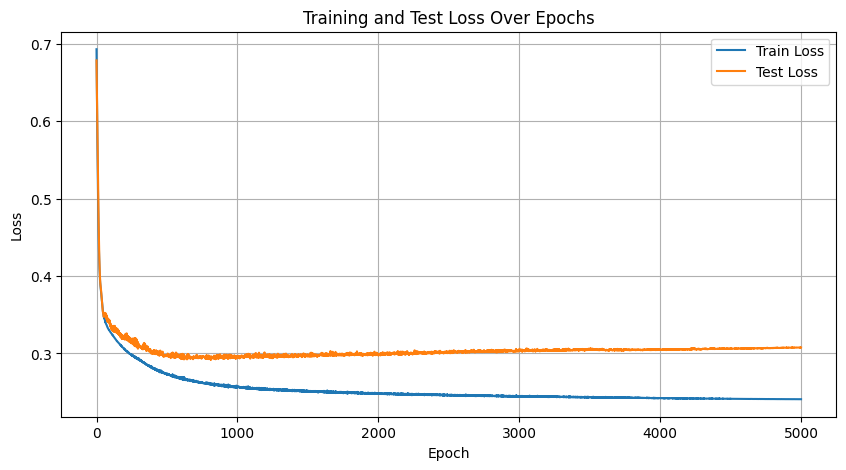

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.0530,  0.0231,  0.9820, -0.1920, -1.6326,  0.9757, -0.1265, -0.0078,
         -0.0124, -0.0170,  0.1176,  0.9773, -1.3029,  0.6662],
        [ 1.0033,  0.3130, -0.0243,  0.4260, -1.3970,  0.3144, -0.3059, -1.7873,
          0.3885,  0.0731,  0.1823,  0.1987,  1.1301,  0.8652],
        [ 0.0500,  0.2901,  1.2918, -0.2143,  0.3235,  0.0282, -0.1447, -0.2627,
         -0.0333,  0.6425,  0.2729, -0.2338, -0.3378,  0.1665],
        [ 2.2293,  0.0717,  0.5583, -0.4024, -0.2429, -0.6434, -0.3404, -0.7409,
          0.1790,  0.1284,  0.0256,  1.2659,  0.0093,  0.3451],
        [-0.3568, -0.3224, -0.0110, -0.1091,  1.6363, -1.2601, -0.6017,  0.5119,
          0.4573, -0.4123, -0.1604, -0.7731,  0.1019,  0.5963],
        [ 0.7618,  0.0860,  0.0166, -0.1029,  0.3070, -0.1293, -0.5676, -0.4243,
          0.2565, -0.0181, -0.0098,  2.0297, -0.9241, -0.5071],
        [-0.5690,  0.3055,  0.0315,  0.1851, -1.3045,  2.3736, -0.2307,  0.0390,


In [9]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params),
    optim.AdamW(adamw_params)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                2,284
Total params: 2,284
Trainable params: 2,284
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 1.21
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 1.21
_orig_mod.linears.0.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

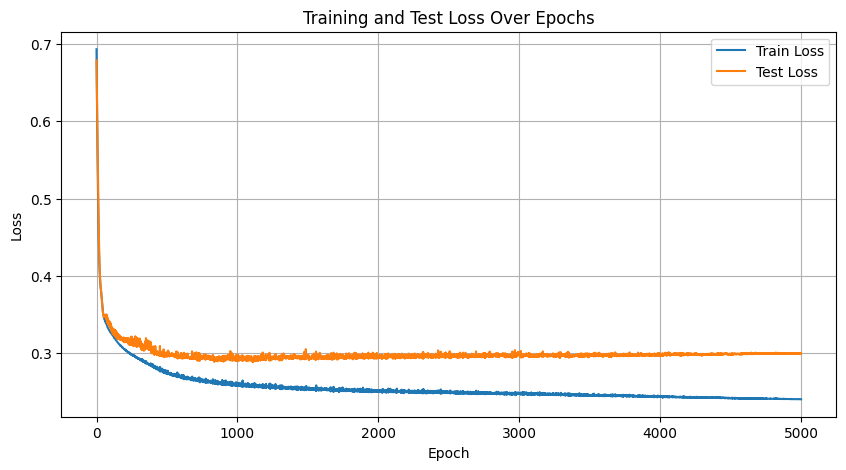

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.0165,  0.0796,  0.2191,  0.0138, -0.2962, -0.4168, -0.2053, -0.5452,
          0.0619, -0.0252,  0.0110,  0.2525,  0.1406,  0.4051],
        [-0.0273, -0.1526,  0.0778,  0.0198, -0.6429,  0.6557,  0.0317, -0.0558,
          0.5089,  0.0139, -0.0109,  0.0848,  0.3979, -0.0477],
        [ 0.1167,  0.1016,  0.3240, -0.1086,  0.0694,  0.1697, -0.2404,  0.0648,
         -0.0274,  0.3594, -0.0890, -0.1906,  0.3435, -0.1914],
        [-0.2974,  0.0830,  0.2631, -0.3597,  0.4255, -0.3400,  0.2721, -0.1239,
          0.0815,  0.0444,  0.2634,  0.5968, -0.3028,  0.1984],
        [-0.4491, -0.0353,  0.2175,  0.2149,  0.0685, -0.1385, -0.0925, -0.1445,
          0.1252, -0.1499,  0.0671,  0.1241,  0.1211,  0.3647],
        [ 0.1521,  0.1014,  0.0494, -0.0224, -0.2762,  0.1030, -0.1632,  0.0467,
          0.0697,  0.0308,  0.0010,  0.5548, -0.3957,  0.1907],
        [-0.3705,  0.2280,  0.2117,  0.0388, -0.1396,  0.5357, -0.2290, -0.2312,


In [10]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.1),
    optim.AdamW(adamw_params, weight_decay=0.1)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                2,284
Total params: 2,284
Trainable params: 2,284
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 1.21
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 1.21
_orig_mod.linears.0.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

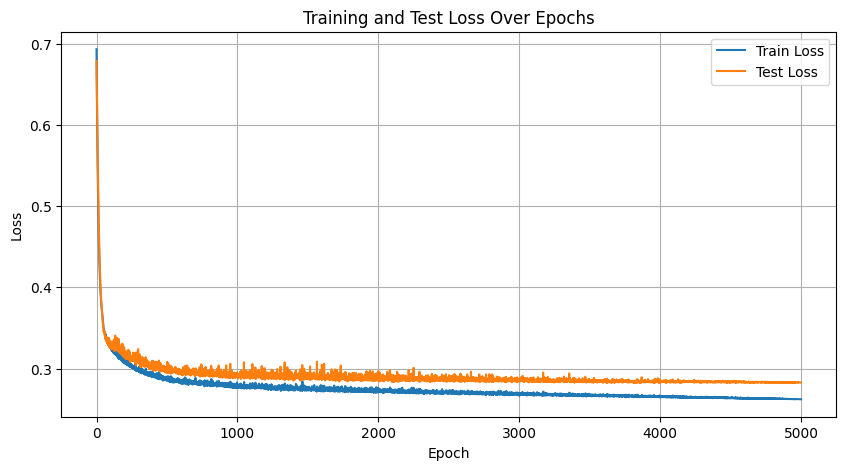

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0105,  0.2967, -0.0445,  0.0059, -0.0827, -0.1214, -0.0347, -0.0152,
          0.1046, -0.0025,  0.1029, -0.0056,  0.1099,  0.1351],
        [-0.0931,  0.0926,  0.0918, -0.0048,  0.1206,  0.1020, -0.1118, -0.0504,
          0.4171, -0.0487,  0.1190,  0.0618, -0.0427, -0.0283],
        [-0.0507,  0.0043,  0.2184,  0.0147, -0.1178,  0.1238, -0.0463,  0.2236,
          0.0297,  0.2900, -0.1334,  0.0962, -0.0739, -0.1671],
        [ 0.0097, -0.0697, -0.0224, -0.1315, -0.0220,  0.1233,  0.1116,  0.1579,
          0.0107,  0.0226,  0.3315,  0.0005,  0.1143,  0.0134],
        [-0.1267,  0.0849,  0.0604,  0.0087, -0.0511, -0.1490, -0.0508,  0.1458,
         -0.0090, -0.0116,  0.0467,  0.0750,  0.0666,  0.0701],
        [-0.0965,  0.0251, -0.0109,  0.0074, -0.2362, -0.1567, -0.0472,  0.1292,
         -0.0113,  0.0017,  0.0101,  0.1962,  0.0527,  0.0869],
        [ 0.0828, -0.0815,  0.0553, -0.1324,  0.1389, -0.1927, -0.1960,  0.1256,


In [17]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=1.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([56, 112])
torch.Size([112, 224])
torch.Size([2, 448])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-19                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-20                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-21                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-6                   

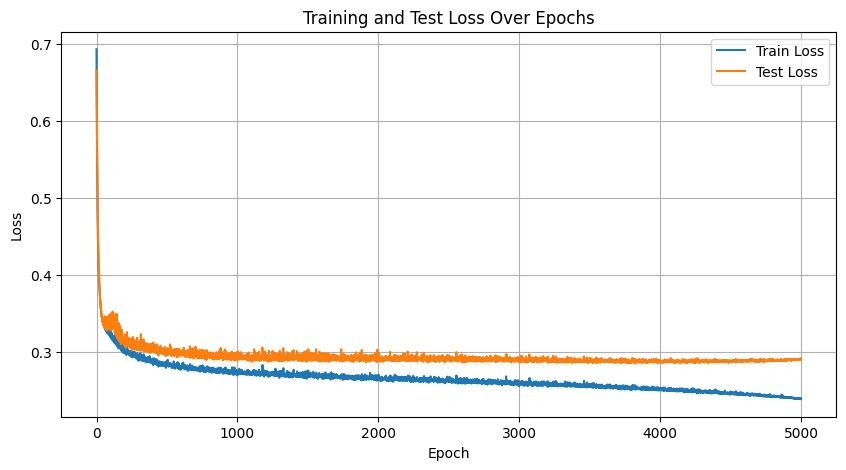

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 2.6287e-02,  1.7661e-01,  7.8509e-02,  1.8077e-03, -4.2591e-02,
         -1.6446e-02, -1.8194e-02, -5.4270e-03,  4.9660e-02,  4.9037e-03,
          4.7971e-02,  1.2768e-02,  3.2330e-02,  5.7347e-03],
        [ 4.1675e-02,  9.1418e-03,  1.7309e-01, -5.0600e-02,  2.2607e-02,
         -1.0787e-01, -4.9839e-02,  1.4549e-02,  8.5518e-02, -9.0655e-02,
         -6.0230e-02,  2.8613e-02,  2.7559e-03,  9.1921e-03],
        [-5.2393e-02,  7.6552e-02,  1.4527e-01, -1.7635e-02, -1.9350e-02,
         -1.3147e-02,  7.5955e-03, -4.1861e-03,  5.0986e-02,  2.4999e-01,
          5.8413e-02,  2.1515e-02, -1.6799e-02, -2.3806e-02],
        [-8.3092e-03,  1.9953e-02, -5.2154e-02,  7.7585e-02, -1.1226e-01,
         -1.1303e-01, -1.2008e-01,  1.2352e-01,  9.8807e-02,  2.8494e-02,
         -1.4429e-01,  2.2485e-02,  6.7879e-02,  2.0238e-02],
        [-5.0457e-02, -1.1230e-03, -1.1166e-04, -7.4543e-02,  3.4005e-02,
          1.2874e-02, -1.4170e-02,  8

In [20]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=5).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=2.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [ ]:
model = torch.compile(StableNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([2, 56])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-7                   --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-8                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-9                   --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-6                        [43152, 28]               --
│    └─ModuleList: 2-7           

KeyboardInterrupt: 

In [10]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, lr=0.01, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0, lr=0.0005)
]

train(model, criterion, optimizers, epochs=10000)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
torch.Size([2])
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-6                        [43152, 28]               --
│    └─Modu

KeyboardInterrupt: 

In [15]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters(): # type: ignore
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, lr=0.01, weight_decay=0.0),
    # optim.AdamW(adamw_params, weight_decay=0.0, lr=0.0005)
]

train(model, criterion, optimizers, epochs=10000)

Muon parameters:
torch.Size([7, 14])
torch.Size([14, 28])
torch.Size([28, 56])
torch.Size([2, 112])

AdamW parameters:
Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 7]                98
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 7]                --
│    └─CReLU: 2-6                        [43152, 28]               --
│    └─ModuleList: 2-11    

KeyboardInterrupt: 